<div dir="rtl" style="text-align:right">
<h1 id="دفتر-المحاضرة-الكامل-1">دفتر المحاضرة الكامل — 1</h1>
<p dir="rtl" style="text-align:right">نقرأ الشرح، ونتوقّع النتيجة، ثم ننفّذ الخلية التالية ونفسّر مخرجاتها قبل أن نتابع. نستخدم <strong>Restart Kernel and Run All</strong> لنتأكد من أن العمل لا يعتمد على جلسة سابقة. تبقى الشروح والاشتقاقات الرياضية والافتراضات الفيزيائية من الفصل محيطة بالخلايا.</p>
</div>

<div dir="rtl" style="text-align:right">
<h2 id="تهيئة-الدفتر-المرفقة">تهيئة الدفتر المرفقة</h2>
<p dir="rtl" style="text-align:right">نختار نواة <strong>Julia 1.12</strong> ونفتح الدفتر من مجلد فصله. تعثر هذه التهيئة المرفقة على بيئة المقرر المسجّلة وتنشئ مجلدًا منفصلًا للأشكال المصدّرة؛ وهي لا تثبّت أي حزم. أوامر التهيئة بنية تحتية، وليست مادة لغوية جديدة تخضع للتقييم.</p>
</div>

In [1]:
import Pkg
course_root = abspath("../..")
if !isfile(joinpath(course_root, "Project.toml"))
    error("Start this notebook from its week folder, e.g. week-1/notebooks")
end
Pkg.activate(course_root; io=devnull)
output_dir = get(ENV, "COURSE_NOTEBOOK_OUTPUT", joinpath(pwd(), "generated", "lecture-ar"))
mkpath(output_dir)
println("Course environment active; figure output directory ready.")

Course environment active; figure output directory ready.


<div dir="rtl" style="text-align:right">
<h1 id="حسابات-julia-الأولى-وملاءمة-أوهلية-موجهة">حسابات <code dir="ltr">Julia</code> الأولى وملاءمة أوهلية موجَّهة</h1>
<p dir="rtl" style="text-align:right">نبدأ الحساب العلمي بالتوقّع لما ينبغي أن يحدث، وجعل الحساب مرئيًا، والسؤال عمّا إذا كانت للنتيجة الوحدات والمعنى الصحيحان. اليوم نستخدم <code dir="ltr">Julia</code> كآلة حاسبة، ثم نتبع وصفة مُعطاة تمضي من البيانات إلى الملاءمة إلى الرسم. وتتضمن الوصفة متجهات وأوامر رسم سنتعلّمها باستقلالية لاحقًا.</p>
<h2 id="أين-نرى-النتيجة">أين نرى النتيجة؟</h2>
<p dir="rtl" style="text-align:right">في <code dir="ltr">REPL</code> الخاص بـ<code dir="ltr">Julia</code>، تؤدي كتابة تعبير إلى تقييمه وعرض قيمته. وفي ملف <code dir="ltr">VS Code</code> يمكن للتقييم أيضًا أن يعرض قيمة في نافذة النتيجة. ذلك العرض مريح، لكنه ليس جزءًا دائمًا من تقرير السكربت. أما <code dir="ltr">println</code> فيرسل نصًا صراحةً إلى الـ<code dir="ltr">REPL</code> أو الطرفية أو مخرجات السكربت؛ ونستخدمه عندما يجب أن يرى القارئ نتيجة.</p>
</div>

<div dir="rtl" style="text-align:right">
<p dir="rtl" style="text-align:right"><strong>قبل التنفيذ:</strong> نتوقّع القيمة أو النص أو الرسم الموصوف أعلاه. هذا هو المثال المقابل من الفصل المكتوب.</p>
</div>

<div dir="rtl" style="text-align:right">
<p dir="rtl" style="text-align:right">هذه تعبيرات تفاعلية منفصلة. نضع كلًّا منها في خلية مستقلة لتظهر كل النتائج، لا النتيجة الأخيرة فقط.</p>
</div>

In [2]:
1 + 1

2

In [3]:
println(1 + 1)

2


<div dir="rtl" style="text-align:right">
<p dir="rtl" style="text-align:right"><strong>تحقّق:</strong> نقارن النتيجة بالشرح الوارد أدناه. تعرض الخلية تلقائيًا تعبيرها الأخير فقط؛ أما <code dir="ltr">println</code> فتكتب النص عمدًا. نعيد تشغيل الخلايا السابقة عند تغيير أي مدخل.</p>
</div>

<div dir="rtl" style="text-align:right">
<p dir="rtl" style="text-align:right">مخرجات مرجعية في الملاحظات المكتوبة (للمقارنة مع مخرجات الخلية الفعلية):</p>
<pre dir="ltr" style="text-align:left" class="text"><code dir="ltr">2</code></pre>
</div>

<div dir="rtl" style="text-align:right">
<p dir="rtl" style="text-align:right">تقييم السطر الأول في الـ<code dir="ltr">REPL</code> أو في عرض المحرّر يُظهر <code dir="ltr">2</code>. والسطر الثاني يطبع <code dir="ltr">2</code> إلى مخرجات الـ<code dir="ltr">REPL</code>. وقد يقيّم السكربت تعبيرات كثيرة دون عرضها، لذا نستخدم <code dir="ltr">println</code> لتقرير نصي مقصود.</p>
<h2 id="julia-كآلة-حاسبة"><code dir="ltr">Julia</code> كآلة حاسبة</h2>
<p dir="rtl" style="text-align:right">في <code dir="ltr">Julia</code> حساب وتجميع وأُسّ ودوال رياضية مألوفة. ومعظم التعبيرات أدناه <em>استدعاءات دوال</em>: اسم دالة يتبعه قوسان، مثل <code dir="ltr">exp(1)</code>. ويطلب الاستدعاء من الدالة المسمّاة أن تعمل على القيم بين القوسين وتعيد نتيجة. وأرجومنتات <code dir="ltr">sin</code> و<code dir="ltr">exp</code> بالراديان عندما تمثّل زوايا. و<code dir="ltr">mod(a,b)</code> باقي القسمة على <code dir="ltr">b</code>؛ و<code dir="ltr">div(a,b)</code> قسمة خارج صحيحة تهمل الباقي بالنسبة للأعداد الصحيحة الموجبة.</p>
</div>

<div dir="rtl" style="text-align:right">
<p dir="rtl" style="text-align:right"><strong>قبل التنفيذ:</strong> نتوقّع القيمة أو النص أو الرسم الموصوف أعلاه. هذا هو المثال المقابل من الفصل المكتوب.</p>
</div>

In [4]:
println(exp(1))
println(sin(pi / 2))
println(mod(17, 5))
println(div(17, 5))

2.718281828459045


1.0
2
3


<div dir="rtl" style="text-align:right">
<p dir="rtl" style="text-align:right"><strong>تحقّق:</strong> نقارن النتيجة بالشرح الوارد أدناه. تعرض الخلية تلقائيًا تعبيرها الأخير فقط؛ أما <code dir="ltr">println</code> فتكتب النص عمدًا. نعيد تشغيل الخلايا السابقة عند تغيير أي مدخل.</p>
</div>

<div dir="rtl" style="text-align:right">
<p dir="rtl" style="text-align:right">مخرجات مرجعية في الملاحظات المكتوبة (للمقارنة مع مخرجات الخلية الفعلية):</p>
<pre dir="ltr" style="text-align:left" class="text"><code dir="ltr">2.718281828459045
1.0
2
3</code></pre>
</div>

<div dir="rtl" style="text-align:right">
<p dir="rtl" style="text-align:right">هنا <code dir="ltr">17 = 3*5 + 2</code>؛ فالخارج 3 والباقي 2.</p>
<p dir="rtl" style="text-align:right">يمكننا إدخال رموز رياضية يونيكود في الـ<code dir="ltr">REPL</code> وفي <code dir="ltr">VS Code</code>. اكتب <code dir="ltr">\pi&lt;Tab&gt;</code> للحصول على <span dir="ltr" class="math inline">\(\pi\)</span>. وفي <code dir="ltr">2pi</code> أو <span dir="ltr" class="math inline">\(2\pi\)</span> تفسّر <code dir="ltr">Julia</code> المعامل العددي كضرب في <code dir="ltr">pi</code>؛ وهو ليس اسم متغير واحد. وبين اسمَي متغيرين علينا كتابة إشارة الضرب صراحةً، كما في <code dir="ltr">mass * speed</code>.</p>
</div>

<div dir="rtl" style="text-align:right">
<p dir="rtl" style="text-align:right"><strong>قبل التنفيذ:</strong> نتوقّع القيمة أو النص أو الرسم الموصوف أعلاه. هذا هو المثال المقابل من الفصل المكتوب.</p>
</div>

In [5]:
println(2pi)
println((2 + 3) * 4)
println(2^3)

6.283185307179586
20
8


<div dir="rtl" style="text-align:right">
<p dir="rtl" style="text-align:right"><strong>تحقّق:</strong> نقارن النتيجة بالشرح الوارد أدناه. تعرض الخلية تلقائيًا تعبيرها الأخير فقط؛ أما <code dir="ltr">println</code> فتكتب النص عمدًا. نعيد تشغيل الخلايا السابقة عند تغيير أي مدخل.</p>
</div>

<div dir="rtl" style="text-align:right">
<p dir="rtl" style="text-align:right">مخرجات مرجعية في الملاحظات المكتوبة (للمقارنة مع مخرجات الخلية الفعلية):</p>
<pre dir="ltr" style="text-align:left" class="text"><code dir="ltr">6.283185307179586
20
8</code></pre>
</div>

<div dir="rtl" style="text-align:right">
<h2 id="أسماء-للقيم-قبل-الفيزياء">أسماء للقيم قبل الفيزياء</h2>
<p dir="rtl" style="text-align:right">إسناد مثل <code dir="ltr">x = 2</code> يربط الاسم على اليسار بالقيمة المحسوبة على اليمين. وهو تعليمة، لا العبارة الجبرية <span dir="ltr" class="math inline">\(x=2\)</span> لكل الأزمنة. ويمكننا بعدها استخدام الأسماء لإظهار حساب.</p>
</div>

<div dir="rtl" style="text-align:right">
<p dir="rtl" style="text-align:right"><strong>قبل التنفيذ:</strong> نتوقّع القيمة أو النص أو الرسم الموصوف أعلاه. هذا هو المثال المقابل من الفصل المكتوب.</p>
</div>

In [6]:
x = 2
y = 3
println(x + y)
println(x^2 + y^2)

5
13


<div dir="rtl" style="text-align:right">
<p dir="rtl" style="text-align:right"><strong>تحقّق:</strong> نقارن النتيجة بالشرح الوارد أدناه. تعرض الخلية تلقائيًا تعبيرها الأخير فقط؛ أما <code dir="ltr">println</code> فتكتب النص عمدًا. نعيد تشغيل الخلايا السابقة عند تغيير أي مدخل.</p>
</div>

<div dir="rtl" style="text-align:right">
<p dir="rtl" style="text-align:right">مخرجات مرجعية في الملاحظات المكتوبة (للمقارنة مع مخرجات الخلية الفعلية):</p>
<pre dir="ltr" style="text-align:left" class="text"><code dir="ltr">5
13</code></pre>
</div>

<div dir="rtl" style="text-align:right">
<p dir="rtl" style="text-align:right">نبقي الأسماء خالية من اللواحق الوحدية ونسجّل كل وحدة في تعليق قصير في نهاية السطر حيث تُعرَّف القيمة، مثل <code dir="ltr">voltage = 2.0 # V</code>. ولا تستنتج <code dir="ltr">Julia</code> الوحدات من التعليق ولا تفرضها، فيحمل التعليق وتوثيق الدوال الوحدات.</p>
<h2 id="سير-عمل-موجه-من-القياس-إلى-النموذج">سير عمل موجَّه من القياس إلى النموذج</h2>
<p dir="rtl" style="text-align:right">تستعيد الوصفة التالية الشرح الكامل لتحليلنا الأول. ونوفّر خطواتها لقراءة الملف والمتجهات والرسم. ويُتوقّع منا تشغيل هذه الخطوات وتفسيرها الآن؛ أما العمل المستقل على <code dir="ltr">CSV</code>/<code dir="ltr">DataFrames</code> فيعود إلى الأسبوع السابع، وإتقان الملاءمة إلى الأسبوع الثامن. والاشتقاق الرياضي خلفية اختيارية منفصلة عن المكافأة المُقيَّمة بثلث نقطة. ولا نعرّف دوالًا قبل الأسبوع الخامس.</p>
<p dir="rtl" style="text-align:right">نفتح دفتر الأسبوع الأول المُعطى أو نشغّل البرنامج المحفوظ من الدليل الذي يحتوي <code dir="ltr">ohm_law.csv</code>. وبيئة المقرر المشتركة تعلن مسبقًا <code dir="ltr">CSV</code> و<code dir="ltr">DataFrames</code> و<code dir="ltr">Plots</code>؛ والتثبيت موصوف في الفصل 0.</p>
<h4 id="ما-هو-ملف-csv">ما هو ملف <code dir="ltr">CSV</code>؟</h4>
<p dir="rtl" style="text-align:right">يخزّن ملف <em>القيم المفصولة بفواصل</em> (<code dir="ltr">CSV</code>) جدولًا كنص عادي. ويعطي السطر الأول عادةً أسماء الأعمدة؛ وكل سطر لاحق صف واحد، وتفصل الفواصل بين العناصر. فمثلًا،</p>
</div>

<div dir="rtl" style="text-align:right">
<h3 id="مثال-لملف-إدخال">مثال لملف إدخال</h3>
<p dir="rtl" style="text-align:right">هذه بيانات CSV، لا كود جوليا. وقراءة الملف الكامل المرفق تجري في سير العمل التالي.</p>
</div>

In [ ]:
current_A,voltage_V
0.10,0.52
0.20,1.01

<div dir="rtl" style="text-align:right">
<p dir="rtl" style="text-align:right">جدول من عمودين: التيار بالأمبير والجهد بالفولت. وتستطيع برامج الجدولة والمختبر عادةً تصدير جدول بصيغة <code dir="ltr">CSV</code>. والنص العادي مفيد لأن الإنسان يستطيع فحص الملف، وتستطيع برامج كثيرة قراءته. وسنستخدم حزمة <a href="https://csv.juliadata.org/stable/"><code dir="ltr">CSV.jl</code></a> لقراءة الملف وحزمة <a href="https://dataframes.juliadata.org/stable/"><code dir="ltr">DataFrames.jl</code></a> لتنظيم الجدول.</p>
<h4 id="الموصل-الأومي">الموصل الأومي</h4>
<p dir="rtl" style="text-align:right">بالنسبة لموصل أومي في حالة ثابتة تقريبًا وفي نظام المجال الضعيف/الاستجابة الخطية، <span dir="ltr" class="math inline">\(V=RI\)</span>. نأخذ الجهد المطبَّق <span dir="ltr" class="math inline">\(V\)</span> بالفولت والتيار الموجب <span dir="ltr" class="math inline">\(I\)</span> بالأمبير في الاتجاه الموجب المختار؛ ووحدات <span dir="ltr" class="math inline">\(R=V/I\)</span> هي <span dir="ltr" class="math inline">\(\Omega\)</span>، ووحدات الموصلية <span dir="ltr" class="math inline">\(G=1/R\)</span> هي S. ويرسي التشتت الانسياق المستقر ويساعد في تحديد المقاومة، لكن التصادمات السريعة وحدها لا تضمن الخطية. ويمكن للتسخين والملامسات والمجالات القوية والأجهزة غير الأومية أن تبطل النموذج. وفحصه المثالي هو <span dir="ltr" class="math inline">\(I=0\Rightarrow V=0\)</span>.</p>
<h4 id="خلفية-رياضية-نموذج-الخط-المستقيم">خلفية رياضية: نموذج الخط المستقيم</h4>
<p dir="rtl" style="text-align:right">للنموذج <span dir="ltr" class="math inline">\(y=ax+b\)</span> ميل <span dir="ltr" class="math inline">\(a\)</span> وحد ثابت <span dir="ltr" class="math inline">\(b\)</span>. ويخبرنا الميل بمقدار تغيّر <span dir="ltr" class="math inline">\(y\)</span> عند ازدياد <span dir="ltr" class="math inline">\(x\)</span> بوحدة واحدة؛ والحد الثابت هو قيمة النموذج عند <span dir="ltr" class="math inline">\(x=0\)</span>.</p>
<h4 id="كيف-نقدم-فكرة-برمجية-جديدة">كيف نقدّم فكرة برمجية جديدة</h4>
<p dir="rtl" style="text-align:right">قبل استخدام أي بناء جديد، نسأل لماذا نحتاجه، ونعرّفه بلغة واضحة، ونعرض صيغته العامة في <code dir="ltr">Julia</code>، ونجرّب أصغر مثال مفيد. ثم نستخدمه في حساب أغنى، ونربطه أخيرًا بمهمة علمية. وعند قراءة الكود نتبع الترتيب نفسه: الغاية، فالصيغة، فالحالة البسيطة، فالتطبيق.</p>
<h4 id="طرق-تشغيل-julia-في-الأسبوع-الأول">طرق تشغيل <code dir="ltr">Julia</code> في الأسبوع الأول</h4>
<ul>
<li dir="rtl" style="text-align:right"><p dir="rtl" style="text-align:right"><strong>طرفية النظام:</strong> نفتح <code dir="ltr">Terminal</code> أو <code dir="ltr">PowerShell</code> أو صدفة <code dir="ltr">Linux</code> ونكتب <code dir="ltr">julia</code>. يبدأ هذا <code dir="ltr">REPL</code> لـ<code dir="ltr">Julia</code> حيث يُقيَّم <code dir="ltr">1+1</code> فورًا.</p></li>
<li dir="rtl" style="text-align:right"><p dir="rtl" style="text-align:right"><strong>طرفية <code dir="ltr">VS Code</code>:</strong> نفتح <strong><code dir="ltr">Terminal &gt; New Terminal</code></strong> داخل <code dir="ltr">VS Code</code> ونكتب <code dir="ltr">julia</code>. وهو الـ<code dir="ltr">REPL</code> نفسه، لكن بجانب ملفات المقرر.</p></li>
<li dir="rtl" style="text-align:right"><p dir="rtl" style="text-align:right"><strong>REPL جوليا في <code dir="ltr">VS Code</code>:</strong> نستخدم لوحة الأوامر ونختار <em><code dir="ltr">Julia: Start REPL</code></em>. ومع فتح ملف <code dir="ltr">.jl</code>، يرسل <code dir="ltr">Shift+Enter</code> السطر الحالي أو الشيفرة المحدّدة إلى ذلك الـ<code dir="ltr">REPL</code> ويبدأه عند الحاجة.</p></li>
<li dir="rtl" style="text-align:right"><p dir="rtl" style="text-align:right"><strong>برنامج كامل محفوظ:</strong> نستخدم <strong><code dir="ltr">Run &gt; Run Without Debugging</code></strong> لتنفيذ ملف <code dir="ltr">.jl</code> النشط من أعلى إلى أسفل. وهذا هو الخيار المعتاد للعمل المُسلَّم لأن التحليل محفوظ وقابل للتكرار.</p></li>
</ul>
<p dir="rtl" style="text-align:right">ولاحقًا سنقدّم الدفاتر، التي تكون خلاياها أكثر تفاعلًا. ولا نخلط بين خلية دفتر وتحليل محفوظ: فكلاهما يحتاج إلى مدخلات واضحة وكود ورسوم واستنتاجات.</p>
<h3 id="نبني-التحليل-خطوة-مرئية-في-كل-مرة">نبني التحليل خطوة مرئية في كل مرة</h3>
<p dir="rtl" style="text-align:right"><strong>الخطوة 1: تحميل الأدوات.</strong> يذكر السطر الأول من السكربت الحزم المثبَّتة التي سيستخدمها البرنامج.</p>
</div>

<div dir="rtl" style="text-align:right">
<p dir="rtl" style="text-align:right"><strong>قبل التنفيذ:</strong> نتوقّع القيمة أو النص أو الرسم الموصوف أعلاه. هذا هو المثال المقابل من الفصل المكتوب.</p>
</div>

In [7]:
using CSV, DataFrames, Plots

<div dir="rtl" style="text-align:right">
<p dir="rtl" style="text-align:right"><strong>تحقّق:</strong> نقارن النتيجة بالشرح الوارد أدناه. تعرض الخلية تلقائيًا تعبيرها الأخير فقط؛ أما <code dir="ltr">println</code> فتكتب النص عمدًا. نعيد تشغيل الخلايا السابقة عند تغيير أي مدخل.</p>
</div>

<div dir="rtl" style="text-align:right">
<p dir="rtl" style="text-align:right">تجعل الكلمة المفتاحية <code dir="ltr">using</code> الأدوات العامة من هذه الحزم متاحة في هذا الملف. فـ<code dir="ltr">CSV</code> يقرأ الملف النصي، و<code dir="ltr">DataFrames</code> يوفّر بنية جدول، و<code dir="ltr">Plots</code> ينشئ رسومًا. وهذا ليس حسابًا بعد: إنه إعلان البرنامج عن الأدوات التي يحتاجها.</p>
<p dir="rtl" style="text-align:right"><strong>الخطوة 2: تحميل الجدول وفحصه.</strong> تفتح السطور التالية الملف وتعرض صفوفه الخمسة الأولى.</p>
<p dir="rtl" style="text-align:right">نحتاج إلى نمطين برمجيين أساسيين قبل ذلك. <em>استدعاء الدالة</em>، الذي رأيناه مع <code dir="ltr">exp</code> و<code dir="ltr">sin</code>، يطلب من أداة مسمّاة إجراء عملية. وصيغته العامة <code dir="ltr">function_name(input1, input2)</code>؛ فمثلًا <code dir="ltr">println("ready")</code> يستدعي <code dir="ltr">println</code> بمدخل نصي واحد. و<em>الإسناد</em> يمنح نتيجة اسمًا قابلةً لإعادة الاستخدام. وصيغته العامة <code dir="ltr">name = expression</code>؛ وتقيّم <code dir="ltr">Julia</code> الطرف الأيمن أولًا ثم تخزّن النتيجة تحت الاسم على اليسار. وأصغر مثال هو <code dir="ltr">x = 2</code>. وتجمع الكتلة التالية هذه الأنماط مع ملف بيانات حقيقي.</p>
<p dir="rtl" style="text-align:right">المدخل الثاني لـ<code dir="ltr">CSV.read</code>، أي <code dir="ltr">DataFrame</code>، يسمّي نوع الجدول الذي نريد استعادته: جدولًا بأعمدة مسمّاة. وتعيد الأداة المساعدة <code dir="ltr">first(data, 5)</code> الصفوف الخمسة الأولى من ذلك الجدول لنفحصها.</p>
</div>

<div dir="rtl" style="text-align:right">
<p dir="rtl" style="text-align:right"><strong>قبل التنفيذ:</strong> نتوقّع القيمة أو النص أو الرسم الموصوف أعلاه. هذا هو المثال المقابل من الفصل المكتوب.</p>
</div>

<div dir="rtl" style="text-align:right">
<p dir="rtl" style="text-align:right">يعرض الدفتر الصفوف الخمسة نفسها كجدول غني بدلًا من طباعة جدول طرفية.</p>
</div>

In [8]:
data = CSV.read(joinpath(course_root, "reveal", "week01", "ohm_law.csv"), DataFrame)
first(data, 5)

Row,current_A,voltage_V
,Float64,Float64
1,0.1,0.52
2,0.2,1.01
3,0.3,1.52
4,0.4,2.0
5,0.5,2.49


<div dir="rtl" style="text-align:right">
<p dir="rtl" style="text-align:right"><strong>تحقّق:</strong> نقارن النتيجة بالشرح الوارد أدناه. تعرض الخلية تلقائيًا تعبيرها الأخير فقط؛ أما <code dir="ltr">println</code> فتكتب النص عمدًا. نعيد تشغيل الخلايا السابقة عند تغيير أي مدخل.</p>
</div>

<div dir="rtl" style="text-align:right">
<p dir="rtl" style="text-align:right">مع الملف المُعطى تكون صفوف البيانات الخمسة المطبوعة:</p>
<table>
<thead>
<tr>
<th style="text-align: right;">صف</th>
<th style="text-align: right;"><code dir="ltr">current_A</code></th>
<th style="text-align: right;"><code dir="ltr">voltage_V</code></th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: right;">1</td>
<td style="text-align: right;">0.1</td>
<td style="text-align: right;">0.52</td>
</tr>
<tr>
<td style="text-align: right;">2</td>
<td style="text-align: right;">0.2</td>
<td style="text-align: right;">1.01</td>
</tr>
<tr>
<td style="text-align: right;">3</td>
<td style="text-align: right;">0.3</td>
<td style="text-align: right;">1.52</td>
</tr>
<tr>
<td style="text-align: right;">4</td>
<td style="text-align: right;">0.4</td>
<td style="text-align: right;">2.0</td>
</tr>
<tr>
<td style="text-align: right;">5</td>
<td style="text-align: right;">0.5</td>
<td style="text-align: right;">2.49</td>
</tr>
</tbody>
</table>
<p dir="rtl" style="text-align:right">نقرأ <code dir="ltr">CSV.read("ohm_law.csv", DataFrame)</code> من اليسار إلى اليمين. فـ<code dir="ltr">CSV.read</code> تعني «استخدم الدالة <code dir="ltr">read</code> التي توفّرها حزمة <code dir="ltr">CSV</code>». ومدخلها الأول اسم الملف؛ ومدخلها الثاني يطلب <code dir="ltr">DataFrame</code>، أي جدولًا بأعمدة مسمّاة. وتخزّن علامة المساواة الجدول الناتج تحت الاسم <code dir="ltr">data</code>. ويأخذ السطر التالي الصفوف الخمسة الأولى ويطبعها في الـ<code dir="ltr">REPL</code> أو الطرفية. وهذا فحص علمي أول: هل أسماء الأعمدة صحيحة، وهل الأعداد معقولة، وهل فتحنا الملف المقصود؟</p>
<p dir="rtl" style="text-align:right"><strong>الخطوة 3: تسمية الكميات الفيزيائية.</strong> نستخرج العمودين إلى أسماء متغيرات خالية من الوحدات تسجّل تعريفاتها الوحدات في تعليق قصير.</p>
<p dir="rtl" style="text-align:right">يمنح <code dir="ltr">DataFrame</code> كل عمود اسمًا. وتختار صيغة الوصول <code dir="ltr">table.column_name</code> عمودًا كاملًا؛ فمثلًا <code dir="ltr">data.current_A</code> تختار القياسات المخزّنة تحت العنوان <code dir="ltr">current_A</code>. ونسند العمودين المختارين إلى اسمين ذوي معنًى:</p>
</div>

<div dir="rtl" style="text-align:right">
<p dir="rtl" style="text-align:right"><strong>قبل التنفيذ:</strong> نتوقّع القيمة أو النص أو الرسم الموصوف أعلاه. هذا هو المثال المقابل من الفصل المكتوب.</p>
</div>

In [9]:
current = data.current_A   # A
voltage = data.voltage_V   # V

5-element Vector{Float64}:
 0.52
 1.01
 1.52
 2.0
 2.49

<div dir="rtl" style="text-align:right">
<p dir="rtl" style="text-align:right"><strong>تحقّق:</strong> نقارن النتيجة بالشرح الوارد أدناه. تعرض الخلية تلقائيًا تعبيرها الأخير فقط؛ أما <code dir="ltr">println</code> فتكتب النص عمدًا. نعيد تشغيل الخلايا السابقة عند تغيير أي مدخل.</p>
</div>

<div dir="rtl" style="text-align:right">
<p dir="rtl" style="text-align:right">الاسمان <code dir="ltr">current</code> و<code dir="ltr">voltage</code> <em>متغيران</em>: تسميتان تتيحان للتعليمات اللاحقة أن تشير إلى قيم يخزّنها البرنامج. ويسند علامة المساواة القيمة على يمينه إلى المتغير على يساره؛ وهو لا يعبّر عن هوية رياضية دائمة. والنقطة في <code dir="ltr">data.current_A</code> تختار العمود المسمّى <code dir="ltr">current_A</code>. ونبقي المعرّفات خالية من الوحدات ونقرأ الوحدة من التعليق في نهاية السطر، وهو تعليق تتجاهله <code dir="ltr">Julia</code>. ونوثّق الوحدات حيث تُعرَّف القيم، وفي توثيق الدوال أو توثيق الواجهة، وعند مواقع الاستدعاء التي قد تكون الوحدات فيها ملتبسة. ونستخدم هنا أعدادًا صحيحة للعدّ وقيم قياس عشرية دون تطوير نظام الأنواع في <code dir="ltr">Julia</code>؛ وسيسمّي الأسبوع الثاني هذه الأنواع البسيطة ويفحصها صراحةً.</p>
<p dir="rtl" style="text-align:right"><strong>الخطوة 4: جعل البيانات مرئية.</strong> قبل ملاءمة أي شيء، نرسم القياسات.</p>
<p dir="rtl" style="text-align:right"><em>المتجه</em> قائمة مرتّبة تُكتب داخل قوسين مربعين، مثل <code dir="ltr">[0, 1]</code>. و<em>مخطط التشتت</em> يمثّل كل زوج من القيم من متجهين بنقطة واحدة، فيتيح لنا رؤية الاتجاهات والقياسات غير المعتادة قبل الوثوق بنموذج. والصيغة الأساسية للاستدعاء <code dir="ltr">scatter(x_values, y_values)</code>. فمثلًا، <code dir="ltr">scatter([0, 1], [0, 1])</code> يرسم نقطتين. وللإعدادات المسمّاة الاختيارية الصيغة <code dir="ltr">keyword=value</code>؛ وهي تضيف تسميات أو تغيّر المظهر دون تغيير البيانات المقيسة. وعلى سبيل المثال، <code dir="ltr">markerstrokewidth=0</code> يزيل الإطار المرسوم حول كل علامة فتبقى النقاط المتداخلة مقروءة. ونطبّق الآن هذه الصيغة على التيار والجهد:</p>
</div>

<div dir="rtl" style="text-align:right">
<p dir="rtl" style="text-align:right"><strong>قبل التنفيذ:</strong> نتوقّع القيمة أو النص أو الرسم الموصوف أعلاه. هذا هو المثال المقابل من الفصل المكتوب.</p>
</div>

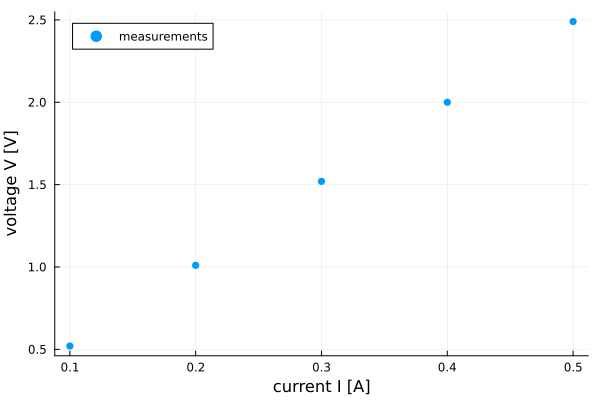

In [10]:
scatter(current, voltage,
    xlabel="current I [A]", ylabel="voltage V [V]",
    label="measurements", markerstrokewidth=0)

<div dir="rtl" style="text-align:right">
<p dir="rtl" style="text-align:right"><strong>تحقّق:</strong> نقارن النتيجة بالشرح الوارد أدناه. تعرض الخلية تلقائيًا تعبيرها الأخير فقط؛ أما <code dir="ltr">println</code> فتكتب النص عمدًا. نعيد تشغيل الخلايا السابقة عند تغيير أي مدخل.</p>
</div>

<div dir="rtl" style="text-align:right">
<figure data-latex-placement="htbp">
<img src="../../assets/figures/lecture-ohm-measurements.png" style="width:72.0%" />
<figcaption>
المخرج الرسومي لاستدعاء <code dir="ltr">scatter</code>: الجهد المقيس يرتفع خطيًا تقريبًا مع التيار.
</figcaption>
</figure>
<p dir="rtl" style="text-align:right">المدخلان الأولان لـ<code dir="ltr">scatter</code> هما الإحداثيان الأفقي والرأسي. والمدخلات اللاحقة <em>أرجومنتات مسمّاة</em>: لكلٍّ منها اسم، مثل <code dir="ltr">xlabel</code>، يتبعه علامة مساواة وقيمة. وهي تتحكم في مظهر الرسم. والتسميات ومفتاح الرسم ليست زينة؛ إنها تخبر القارئ بما قيس وبأي وحدات.</p>
<h4 id="الرسم-جزء-من-الحساب">الرسم جزء من الحساب</h4>
<p dir="rtl" style="text-align:right">لا نثق بملاءمة لم نرسمها. فقد يخفي الجواب العددي قيمة شاذة، أو اتجاهًا غير خطي، أو خطأ في الوحدات، أو عمودين مبدَّلين.</p>
<p dir="rtl" style="text-align:right"><strong>الخطوة 5: ملاءمة خط من تعريفه.</strong> للخط التجريبي <span dir="ltr" class="math inline">\(V=RI+V_0\)</span>، الباقي للقياس <span dir="ltr" class="math inline">\(i\)</span> هو الفرق الرأسي <span dir="ltr" class="math display">\[r_i=V_i-(RI_i+V_0).\]</span> ونختار الخط الذي يصغّر مجموع مربعات الفروق، <span dir="ltr" class="math display">\[S(R,V_0)=\sum_{i=1}^n\left[V_i-(RI_i+V_0)\right]^2.\]</span> فالتربيع يمنع إلغاء الفروق الموجبة والسلبية بعضها بعضًا، ويعاقب الفرق الكبير أكثر من الصغير. وهذا هو تعريف المربعات الصغرى الخطية غير الموزونة: فهو يعامل كل القياسات على أنها متساوية في الموثوقية. وسندرس التصغير لاحقًا في المقرر. وفي الأسبوع الأول نستخدم الصيغ المباشرة الناتجة بدل مُصغِّر عام أو طريقة مصفوفات.</p>
<p dir="rtl" style="text-align:right">ولأصغر مثال دقيق، تقع النقاط الثلاث <span dir="ltr" class="math inline">\((0,1)\)</span> و<span dir="ltr" class="math inline">\((1,3)\)</span> و<span dir="ltr" class="math inline">\((2,5)\)</span> كلها على <span dir="ltr" class="math inline">\(y=2x+1\)</span>. فميل أفضل ملاءمة <span dir="ltr" class="math inline">\(2\)</span>، وحدّها الثابت <span dir="ltr" class="math inline">\(1\)</span>، وكل البواقي صفر. والقياسات الحقيقية لا تقع بالضبط على خط واحد، لذا يكون حساب قانون أوم أدناه هو الحالة الأغنى.</p>
<h4 id="صيغ-الملاءمة-الخطية-المباشرة">صيغ الملاءمة الخطية المباشرة</h4>
<p dir="rtl" style="text-align:right">نكتب <span dir="ltr" class="math inline">\(\overline{I}\)</span> لمتوسط التيار و<span dir="ltr" class="math inline">\(\overline{V}\)</span> لمتوسط الجهد. والميل والحد الثابت لأفضل ملاءمة هما <span dir="ltr" class="math display">\[R=\frac{\sum_{i=1}^n(I_i-\overline{I})(V_i-\overline{V})}{\sum_{i=1}^n(I_i-\overline{I})^2},
\qquad V_0=\overline{V}-R\overline{I}.\]</span> والبسط موجب عندما ينزع التيار والجهد إلى الزيادة معًا. والمقام يقيس مقدار تشتّت قيم التيار حول متوسطها. ولا تكون الملاءمة ممكنة إذا تساوت كل قيم التيار، لأنه لا يمكن عندئذ تحديد ميل. ويُختار الحد الثابت بحيث يمرّ الخط الملائم عبر <span dir="ltr" class="math inline">\((\overline{I},\overline{V})\)</span>.</p>
<h4 id="خلفية-رياضية-اختيارية-من-أين-تأتي-صيغ-الملاءمة">خلفية رياضية اختيارية: من أين تأتي صيغ الملاءمة؟</h4>
<p dir="rtl" style="text-align:right">هذا الصندوق لمن يريد أن يستشرف ما سيأتي. وهو غير مطلوب في الأسبوع الأول. نبحث عن قيمة صغرى لـ<span dir="ltr" class="math inline">\(S(R,V_0)\)</span>، وهي تعتمد على معاملين قابلين للضبط. وعند قيمة صغرى ناعمة، لا يمكن لتغيير أيٍّ من المعاملين بمقدار صغير أن يخفض <span dir="ltr" class="math inline">\(S\)</span>، لذا يجب أن يختفي كلا المشتقيّن الجزئيين.</p>
<p dir="rtl" style="text-align:right">نشتق أولًا بالنسبة للحد الثابت: <span dir="ltr" class="math display">\[0=\frac{\partial S}{\partial V_0}
=-2\sum_{i=1}^{n}\left[V_i-(RI_i+V_0)\right].\]</span> وبالقسمة على <span dir="ltr" class="math inline">\(-2n\)</span> وإعادة الترتيب نحصل على <span dir="ltr" class="math inline">\(V_0=\overline{V}-R\overline{I}\)</span>. لذا يمرّ الخط الملائم عبر نقطة البيانات المتوسطة.</p>
<p dir="rtl" style="text-align:right">ثم نشتق بالنسبة للميل <span dir="ltr" class="math inline">\(R\)</span>: <span dir="ltr" class="math display">\[0=\frac{\partial S}{\partial R}
=-2\sum_{i=1}^{n}I_i\left[V_i-(RI_i+V_0)\right].\]</span> نعوّض عن عبارة <span dir="ltr" class="math inline">\(V_0\)</span>. فيصبح الباقي <span dir="ltr" class="math inline">\((V_i-\overline{V})-R(I_i-\overline{I})\)</span>. وباستخدام <span dir="ltr" class="math inline">\(\sum_i(I_i-\overline{I})=0\)</span> و<span dir="ltr" class="math inline">\(\sum_i(V_i-\overline{V})=0\)</span>، تصبح المعادلة المتبقية <span dir="ltr" class="math display">\[\sum_{i=1}^{n}(I_i-\overline{I})(V_i-\overline{V})
=R\sum_{i=1}^{n}(I_i-\overline{I})^2.\]</span> وبحلّ هذه المعادلة لإيجاد <span dir="ltr" class="math inline">\(R\)</span> نحصل على صيغة الميل المباشرة أعلاه؛ وبتعويض ذلك الميل في <span dir="ltr" class="math inline">\(V_0=\overline{V}-R\overline{I}\)</span> نحصل على الحد الثابت. وفي الأسبوع الثامن، سيصبح إتقان المربعات الصغرى والتصغير لاحقًا أداةً منتظمة في المقرر.</p>
<p dir="rtl" style="text-align:right">يجب أن تطبّق الصيغ العملية نفسها على كل متجه قياسات. والنقطة على عامل حسابي تخبر <code dir="ltr">Julia</code> أن تطبّق تلك العملية عنصرًا بعنصر. والنمط العام هو <code dir="ltr">vector .operator value</code>. ويبدأ الرمز <code dir="ltr">#</code> تعليقًا: تتجاهل <code dir="ltr">Julia</code> بقية ذلك السطر، بينما يستطيع القارئ استخدامه شرحًا. فمثلًا،</p>
</div>

<div dir="rtl" style="text-align:right">
<p dir="rtl" style="text-align:right"><strong>قبل التنفيذ:</strong> نتوقّع القيمة أو النص أو الرسم الموصوف أعلاه. هذا هو المثال المقابل من الفصل المكتوب.</p>
</div>

In [11]:
values = [1, 2, 3]
squared = values .^ 2     # [1, 4, 9]

3-element Vector{Int64}:
 1
 4
 9

<div dir="rtl" style="text-align:right">
<p dir="rtl" style="text-align:right"><strong>تحقّق:</strong> نقارن النتيجة بالشرح الوارد أدناه. تعرض الخلية تلقائيًا تعبيرها الأخير فقط؛ أما <code dir="ltr">println</code> فتكتب النص عمدًا. نعيد تشغيل الخلايا السابقة عند تغيير أي مدخل.</p>
</div>

<div dir="rtl" style="text-align:right">
<p dir="rtl" style="text-align:right">نطبّق الآن العمليات المنقوطة على كل قياسات التيار والجهد. ويأتي أولًا مُجمِّلان للمتجه: <code dir="ltr">length(current)</code> يعيد عدد القياسات، و<code dir="ltr">sum(current)</code> يجمع عناصر المتجه. ونستخدمهما معًا لحساب المتوسطين. وينفّذ الكود الصيغ مباشرة، فتبقى كل كمية مرئية:</p>
</div>

<div dir="rtl" style="text-align:right">
<p dir="rtl" style="text-align:right"><strong>قبل التنفيذ:</strong> نتوقّع القيمة أو النص أو الرسم الموصوف أعلاه. هذا هو المثال المقابل من الفصل المكتوب.</p>
</div>

In [12]:
n = length(current)
I_bar = sum(current) / n   # A
V_bar = sum(voltage) / n   # V
dI = current .- I_bar      # A
dV = voltage .- V_bar      # V
resistance = sum(dI .* dV) / sum(dI .^ 2)   # ohm
offset = V_bar - resistance * I_bar   # V

0.029000000000000137

<div dir="rtl" style="text-align:right">
<p dir="rtl" style="text-align:right"><strong>تحقّق:</strong> نقارن النتيجة بالشرح الوارد أدناه. تعرض الخلية تلقائيًا تعبيرها الأخير فقط؛ أما <code dir="ltr">println</code> فتكتب النص عمدًا. نعيد تشغيل الخلايا السابقة عند تغيير أي مدخل.</p>
</div>

<div dir="rtl" style="text-align:right">
<p dir="rtl" style="text-align:right">يعدّ <code dir="ltr">length(current)</code> القياسات ويجمع <code dir="ltr">sum(...)</code> عناصر متجه. والنقطة في <code dir="ltr">.-</code> و<code dir="ltr">.*</code> و<code dir="ltr">.^</code> تعني «طبّق هذه العملية على العناصر المتقابلة». وبهذا يحتوي <code dir="ltr">dI .* dV</code> على حاصل ضرب <span dir="ltr" class="math inline">\((I_i-\overline{I})(V_i-\overline{V})\)</span> لكل قياس، جاهزًا ليجمعها <code dir="ltr">sum</code>. وتفرّق <code dir="ltr">Julia</code> عمدًا بين العمليات العنصرية وعمليات المصفوفات؛ فضرب المصفوفات العادي غير معرَّف لمتجهين من قياسات متقابلة. وفي الأسبوع الأول نستخدم الصيغ المنقوطة كلما كان الحساب مقصودًا أن يعمل على كل قياس منفصلًا.</p>
<p dir="rtl" style="text-align:right"><strong>الخطوة 6: وضع النموذج على الرسم نفسه والإبلاغ عن النتيجة.</strong></p>
<p dir="rtl" style="text-align:right">نبني رسم النموذج من نسخة جديدة من النقاط المقيسة، ثم نضيف الخط الملائم إلى الرسم نفسه. وفي الصيغة <code dir="ltr">plot!(x, y)</code> تدل علامة التعجب على أن رسمًا قائمًا يُعدَّل؛ ثم يحفظ <code dir="ltr">savefig("name.png")</code> الرسم الحالي. واستدعاء <code dir="ltr">plot()</code> بلا بيانات يبدأ رسمًا جديدًا فارغًا. وللإبلاغ بالأعداد، تُدرج <code dir="ltr">$(expression)</code> قيمة محسوبة في سلسلة نصية، ويحدّ <code dir="ltr">round(value, digits=3)</code> من خاناتها العشرية المعروضة. وفيما يلي مثال صغير لكل صيغة، على رسمه الخاص:</p>
</div>

<div dir="rtl" style="text-align:right">
<p dir="rtl" style="text-align:right"><strong>قبل التنفيذ:</strong> نتوقّع القيمة أو النص أو الرسم الموصوف أعلاه. هذا هو المثال المقابل من الفصل المكتوب.</p>
</div>

value = 1.23


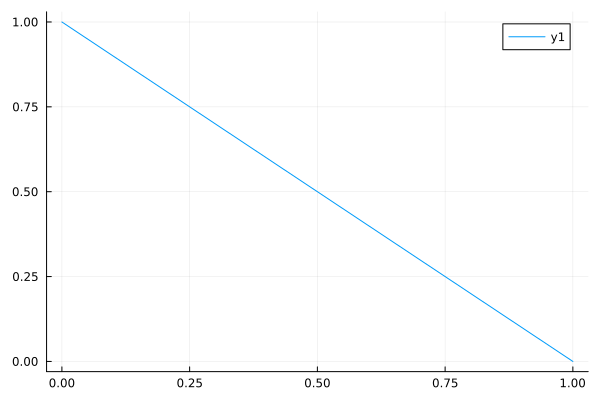

In [13]:
plot()
plot!([0, 1], [1, 0])
savefig(joinpath(output_dir, "example.png"))
rounded = round(1.2345, digits=2)
println("value = $(rounded)")
display(Plots.current())

<div dir="rtl" style="text-align:right">
<p dir="rtl" style="text-align:right"><strong>تحقّق:</strong> نقارن النتيجة بالشرح الوارد أدناه. تعرض الخلية تلقائيًا تعبيرها الأخير فقط؛ أما <code dir="ltr">println</code> فتكتب النص عمدًا. نعيد تشغيل الخلايا السابقة عند تغيير أي مدخل.</p>
</div>

<div dir="rtl" style="text-align:right">
<p dir="rtl" style="text-align:right">مخرجات مرجعية في الملاحظات المكتوبة (للمقارنة مع مخرجات الخلية الفعلية):</p>
<pre dir="ltr" style="text-align:left" class="text"><code dir="ltr">value = 1.23</code></pre>
</div>

<div dir="rtl" style="text-align:right">
<p dir="rtl" style="text-align:right">وتعيد كتلة الإبلاغ العلمي الكاملة إنشاء مخطط القياسات وتضيف النموذج الملائم، فلا يبقى الخط اللعبة في الرسم. وعلى خط النموذج، يضبط <code dir="ltr">linewidth=2</code> عرض الخط:</p>
</div>

<div dir="rtl" style="text-align:right">
<p dir="rtl" style="text-align:right"><strong>قبل التنفيذ:</strong> نتوقّع القيمة أو النص أو الرسم الموصوف أعلاه. هذا هو المثال المقابل من الفصل المكتوب.</p>
</div>

R = 4.93 ohm


offset = 0.029 V


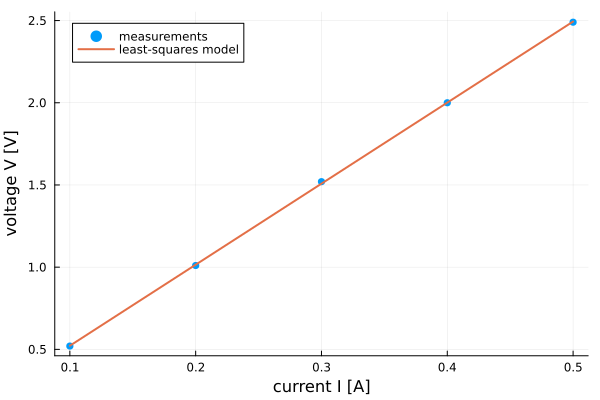

In [14]:
scatter(current, voltage,
    xlabel="current I [A]", ylabel="voltage V [V]",
    label="measurements", markerstrokewidth=0)
plot!(current, resistance .* current .+ offset,
    label="least-squares model", linewidth=2)
savefig(joinpath(output_dir, "ohm_law_fit.png"))

println("R = $(round(resistance, digits=3)) ohm")
println("offset = $(round(offset, digits=3)) V")
display(Plots.current())

<div dir="rtl" style="text-align:right">
<p dir="rtl" style="text-align:right"><strong>تحقّق:</strong> نقارن النتيجة بالشرح الوارد أدناه. تعرض الخلية تلقائيًا تعبيرها الأخير فقط؛ أما <code dir="ltr">println</code> فتكتب النص عمدًا. نعيد تشغيل الخلايا السابقة عند تغيير أي مدخل.</p>
</div>

<div dir="rtl" style="text-align:right">
<p dir="rtl" style="text-align:right">مخرجات مرجعية في الملاحظات المكتوبة (للمقارنة مع مخرجات الخلية الفعلية):</p>
<pre dir="ltr" style="text-align:left" class="text"><code dir="ltr">R = 4.93 ohm
offset = 0.029 V</code></pre>
</div>

<div dir="rtl" style="text-align:right">
<figure data-latex-placement="htbp">
<img src="../../assets/figures/lecture-ohm-fit.png" style="width:72.0%" />
<figcaption>
المخرج الرسومي بعد <code dir="ltr">plot!</code>: نموذج المربعات الصغرى مرسوم على القياسات.
</figcaption>
</figure>
<p dir="rtl" style="text-align:right">تضرب النقطة في <code dir="ltr">resistance .* current</code> المقاومة العددية في كل قيمة تيار. ثم تضيف النقطة في <code dir="ltr">.+ offset</code> الحد الثابت إلى كل نتيجة. وتعبّر علامة التعجب في <code dir="ltr">plot!</code> عن «أضف إلى الرسم القائم» بدل إنشاء رسم جديد. ويحفظ استدعاء <code dir="ltr">savefig</code> التالي الرسم الحالي في ملف <code dir="ltr">PNG</code> داخل مجلد العمل.</p>
<p dir="rtl" style="text-align:right"><strong>الخطوة 7: فحص البواقي.</strong> الخط الملائم نموذج، لا برهانًا على جودة النموذج. نرسم البواقي لنتحقق هل تتقلّب حول الصفر دون نمط ظاهر. والصيغة المعدِّلة <code dir="ltr">hline!</code> تضيف خطًا أفقيًا إلى الرسم الحالي، ونستخدمها للمرجع الصفري:</p>
</div>

<div dir="rtl" style="text-align:right">
<p dir="rtl" style="text-align:right"><strong>قبل التنفيذ:</strong> نتوقّع القيمة أو النص أو الرسم الموصوف أعلاه. هذا هو المثال المقابل من الفصل المكتوب.</p>
</div>

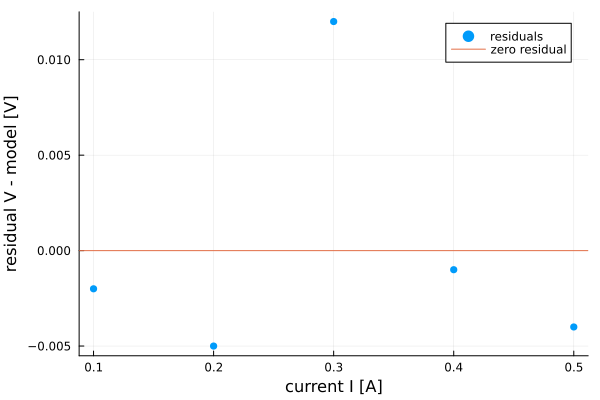

In [15]:
residual = voltage .- (resistance .* current .+ offset)   # V
scatter(current, residual,
    xlabel="current I [A]", ylabel="residual V - model [V]",
    label="residuals", markerstrokewidth=0)
hline!([0], label="zero residual")
savefig(joinpath(output_dir, "ohm_law_residuals.png"))
display(Plots.current())

<div dir="rtl" style="text-align:right">
<p dir="rtl" style="text-align:right"><strong>تحقّق:</strong> نقارن النتيجة بالشرح الوارد أدناه. تعرض الخلية تلقائيًا تعبيرها الأخير فقط؛ أما <code dir="ltr">println</code> فتكتب النص عمدًا. نعيد تشغيل الخلايا السابقة عند تغيير أي مدخل.</p>
</div>

<div dir="rtl" style="text-align:right">
<figure data-latex-placement="htbp">
<img src="../../assets/figures/lecture-ohm-residuals.png" style="width:72.0%" />
<figcaption>
المخرج الرسومي لحساب البواقي: كل البواقي صغيرة وتقع على جانبي الصفر.
</figcaption>
</figure>
<p dir="rtl" style="text-align:right">يحفظ استدعاء <code dir="ltr">savefig</code> الثاني رسم البواقي الذي يكون حاليًا عند تلك النقطة. وإذا انحنت البواقي بانتظام فوق الصفر وتحته، فقد يكون الخط المستقيم هو النموذج الخطأ. وإذا كان باقٍ واحد أكبر بكثير من الآخرين، نفحص ذلك القياس بدل الوثوق الصامت بالملاءمة. وعند هذه النقطة لدينا برنامج علمي صغير كامل: يقرأ بيانات، ويفحصها، ويحفظ رسومًا، ويحسب معاملات نموذج، ويوصل معناها بالوحدات.</p>
<h4 id="تشتت-القياس-وخطأ-النموذج-والأرقام-المعروضة">تشتّت القياس وخطأ النموذج والأرقام المعروضة</h4>
<p dir="rtl" style="text-align:right">تشتّت القياس تباين في المشاهدات المتكررة ينتج عن دقة الجهاز وظروف التجربة. وخطأ النموذج عدم توافق منتظم بين النموذج المختار والنظام الفيزيائي؛ ونمط بواقٍ منحنٍ دليل على عدم توافق كهذا. وهذان يختلفان عن تدوير العرض. فطباعة ثلاث خانات عشرية تجعل المخرجات متسقة، لكنها لا تثبت أن الخانات الثلاث كلها ذات دلالة فيزيائية. ويجب أن يتبع عدد الأرقام المعنوية المبرَّر في النهاية من عدم يقين القياس، وهو ما سنعالجه بتفصيل أكبر لاحقًا.</p>
<p dir="rtl" style="text-align:right">الدليل الموجَّه لسير العمل هذا في فصل التمرين الأول، <em>بيانات السقوط الحر</em>.</p>
<h4 id="خلفية-فيزيائية-الوحدات-في-المعاملات-الملائمة">خلفية فيزيائية: الوحدات في المعاملات الملائمة</h4>
<p dir="rtl" style="text-align:right">إذا كانت لـ<span dir="ltr" class="math inline">\(y\)</span> وحدات الفولت ولـ<span dir="ltr" class="math inline">\(x\)</span> وحدات الأمبير، فلوحدات الميل فولت لكل أمبير، أي أوم. وللحد الثابت الوحدات نفسها التي لـ<span dir="ltr" class="math inline">\(y\)</span>. وتحليل الوحدات طريقة بسيطة لالتقاط أخطاء الملاءمة. ولاحقًا يمكن لحزمة مثل <code dir="ltr">Unitful.jl</code> أن تحمل الوحدات مع القيم في الكود؛ ويبقى الاستدلال الفيزيائي نفسه.</p>
<h2 id="التمرين-قياس-ثابت-النابض">التمرين: قياس ثابت النابض</h2>
<p dir="rtl" style="text-align:right">ننقل التحليل نفسه إلى نابض. قياساتنا هي الاستطالة <span dir="ltr" class="math inline">\(x\)</span> بالمتر والقوة المؤثرة <span dir="ltr" class="math inline">\(F\)</span> بالنيوتن؛ والنموذج الملائم هو <span dir="ltr" class="math inline">\(F=kx+F_0\)</span>. وخلافًا لملاءمة تكون فيها الاستطالة على المحور الرأسي، يكون الميل هنا هو ثابت النابض <span dir="ltr" class="math inline">\(k\)</span> بوحدة N/m مباشرة. ونتوقّع أولًا ميلًا موجبًا ونتحقق من أن الحد الثابت له وحدة القوة.</p>
<p dir="rtl" style="text-align:right">قبل الجلسة نفتح دفتر تمرين الأسبوع الأول ونحدّد خلاياه المُعطاة وخلايا الملاءمة. وفي أول عشرين دقيقة نفحص المحاور، ونتابع ملاءمة واحدة، ونشرح الميل والحد الثابت وباقيًا واحدًا. ثم نبدأ واجب السقوط الحر المستقل بمساعدة طاقم التدريس. ومن الفحوص المفيدة أن نشرح لماذا يغيّر تبديل المحورين وحدات الميل الملائم ومعناه؛ وفي البيانات المشوّشة، لا تكافئ إعادة الملاءمة بمحورين مبدَّلين عمومًا مقلوب الميل.</p>
<h2 id="الواجب-الأساسي-استنتاج-الجاذبية-من-قياسات-السقوط-الحر">الواجب الأساسي: استنتاج الجاذبية من قياسات السقوط الحر</h2>
<p dir="rtl" style="text-align:right">نستقصي هل تتفق مسافات السقوط المقيسة مع الإطلاق من السكون تحت جاذبية منتظمة تقريبًا. نأخذ المسافة موجبة نحو الأسفل، فيكون <span dir="ltr" class="math inline">\(y(t)=\tfrac12gt^2+b\)</span>، مع <span dir="ltr" class="math inline">\(g&gt;0\)</span> بوحدة m/s<span dir="ltr" class="math inline">\(^2\)</span> والحد الثابت <span dir="ltr" class="math inline">\(b\)</span> بالمتر. والتحويل المُعطى <code dir="ltr">t_s .^ 2</code> يجعل الزمن المربّع هو الإحداثي الأفقي. نلائم <span dir="ltr" class="math inline">\(y=a t^2+b\)</span> ونفسّر <span dir="ltr" class="math inline">\(g=2a\)</span>؛ وعامل الاثنين يأتي من معادلة الحركة، لا من اصطلاح برمجي.</p>
<p dir="rtl" style="text-align:right">نعمل على هذه المراحل:</p>
<ol type="1">
<li dir="rtl" style="text-align:right"><p dir="rtl" style="text-align:right">نفحص الملف المُعطى <code dir="ltr">free_fall.csv</code>: نحدّد عمودَي الزمن والمسافة ووحدتيهما وعدد المشاهدات.</p></li>
<li dir="rtl" style="text-align:right"><p dir="rtl" style="text-align:right">نتوقّع شكل <span dir="ltr" class="math inline">\(y\)</span> بدلالة <span dir="ltr" class="math inline">\(t\)</span> وشكل <span dir="ltr" class="math inline">\(y\)</span> بدلالة <span dir="ltr" class="math inline">\(t^2\)</span> قبل تشغيل الملاءمة. نطبّق الوصفة المُعطاة ونحتفظ بالتنبؤات وبواقي المقيس ناقص المتوقّع.</p></li>
<li dir="rtl" style="text-align:right"><p dir="rtl" style="text-align:right">نرسم المشاهدات بعلامات مميزة، ونركّب النموذج الملائم عليها، وننشئ رسمًا منفصلًا للبواقي مع مرجع صفري. ونسمّي كل محور بكميته ووحدته.</p></li>
<li dir="rtl" style="text-align:right"><p dir="rtl" style="text-align:right">نحفظ ملفي <code dir="ltr">PNG</code>/<code dir="ltr">PDF</code> المطلوبين ونذكر <span dir="ltr" class="math inline">\(g\)</span> والحد الثابت الملائمين. ونشرح هل تدعم البواقي النموذج على المجال المقيس، ونسمّي افتراضًا واحدًا لا تستطيع الملاءمة إثباته.</p></li>
<li dir="rtl" style="text-align:right"><p dir="rtl" style="text-align:right">نشغّل فحص الخط المضبوط المنشور ونقدّم الشيفرة العددية ومخرجات الشكل/التقرير المحدَّدة في ورقة الواجب.</p></li>
</ol>
<p dir="rtl" style="text-align:right">نقدّم قطعةً عددية تستخدم أسماء المدخلات والمخرجات المُعطاة، ويوفّر المصحّح غلاف الدالة الذي يستدعيها؛ وتعريف دالة <code dir="ltr">Julia</code> ليس جزءًا من عمل الأسبوع الأول. ومن المفيد أن نُبقي ورقة الواجب بجانبنا، فهي المكان الذي تُنشر فيه الاختبارات العامة الدقيقة والتحمّلات والمجالات وأسماء الملفات. ويجب ألّا يؤدي تقريب إجابة معروضة إلى تقريب القيم المستخدمة في التنبؤات أو التصحيح.</p>
<h2 id="مكافأة-اختيارية-اجعل-رسما-علميا-يوصل-الفكرة">مكافأة اختيارية: اجعل رسمًا علميًا يوصّل الفكرة</h2>
<p dir="rtl" style="text-align:right">هذه المكافأة اختيارية، وليست شرطًا مسبقًا لعمل لاحق، وغير ممتحنة. وكل مكافأة نُنجزها تساوي <strong>ثلث نقطة من العلامة النهائية</strong>.</p>
<p dir="rtl" style="text-align:right">بعد قراءة مستقلة مدتها 10–15 دقيقة، نحسّن رسمًا أوهليًا مصغّرًا مُعطى. هنا الجهد هو الإحداثي الأفقي والتيار هو الإحداثي الرأسي، لذا يكون ميل النموذج هو الموصلية بوحدة S لا المقاومة بوحدة <span dir="ltr" class="math inline">\(\Omega\)</span>. ونحدّد سلسلة التيار المقيس وسلسلة التيار الملائم قبل تغيير مظهرهما.</p>
<p dir="rtl" style="text-align:right">نضيف العنوان المطلوب، والتسميات مع الوحدات، ومدخلات مفتاح الرسم، وعلامات المشاهدات، وخط النموذج، والإطار، وحجم اللوحة، ثم نصدّر <code dir="ltr">PNG</code> و<code dir="ltr">PDF</code>. وتوفّر الشيفرة العددية السلسلتين المتوافقتين المتحقَّق منهما؛ وتُقيَّم الصور منفصلة وفق قائمة تحقّق صريحة. ونتأكد أن تغيير تسمية أو نمط خط لا يغيّر قياسًا. وتحدّد ورقة المكافأة السلاسل النصية وأسماء الملفات بدقة، فيكون الاكتمال، لا الذوق ولا مطابقة البكسل، هو معيار النجاح.</p>
<h2 id="استكشاف-إضافي-منحنيات-ليساجو">استكشاف إضافي: منحنيات ليساجو</h2>
<p dir="rtl" style="text-align:right">في هذا الاستقصاء الاختياري غير الممتحن نستخدم وصفة رسم مُعطاة لـ <span dir="ltr" class="math display">\[x(t)=A\cos(at+\delta),\qquad y(t)=B\sin(bt).\]</span> هنا <span dir="ltr" class="math inline">\(t\)</span> بالثواني، و<span dir="ltr" class="math inline">\(a,b\)</span> ترددان زاويان بوحدة rad/s، و<span dir="ltr" class="math inline">\(\delta\)</span> طور بالراديان، و<span dir="ltr" class="math inline">\(A,B\)</span> يحدّدان سعتي الإحداثيين. وتصف هذه المنحنيات حركتين جيبيتين مستقلتين ننظر إليهما معًا؛ وهي ليست مسارات تحت قوة جاذبية مركزية.</p>
<p dir="rtl" style="text-align:right">نُبقي السعتين ثابتتين ونقارن نسخ الترددات <span dir="ltr" class="math inline">\(1:1\)</span> و<span dir="ltr" class="math inline">\(2:1\)</span> و<span dir="ltr" class="math inline">\(3:2\)</span>. ثم، لنسخة واحدة، نغيّر الطور من <span dir="ltr" class="math inline">\(0\)</span> إلى <span dir="ltr" class="math inline">\(\pi/2\)</span>. نحفظ رسمين متباينين ونكتب تخمينًا عن الإغلاق والتناظر. ونتحقق هل يغيّر مدى زمني أطول منحنى يبدو مفتوحًا: فنافذة الرسم المحدودة ليست دليلًا على عدم الإغلاق. ولا يضيف هذا النشاط أي صياغة برمجية مطلوبة، وهو منفصل عن المكافأة المُقيَّمة.</p>
</div>

<div dir="rtl" style="text-align:right">
<h2 id="أمثلة-صغيرة-وفحوص-مذكورة-في-الفصل">أمثلة صغيرة وفحوص مذكورة في الفصل</h2>
<p dir="rtl" style="text-align:right">تجعل الخلايا التالية الأمثلة المضمّنة والفحوص المحلولة في الفصل قابلة للتنفيذ. وهي لا تضيف حلولًا للواجب.</p>
</div>

<div dir="rtl" style="text-align:right">
<p dir="rtl" style="text-align:right">استدعاء صغير لدالة قائمة يعلن الجاهزية؛ أما تعريف الدوال فينتمي إلى الأسبوع 5.</p>
</div>

In [16]:
println("ready")

ready


<div dir="rtl" style="text-align:right">
<p dir="rtl" style="text-align:right">أصغر مثال لمخطط التشتت يحتوي نقطتين معلومتين.</p>
</div>

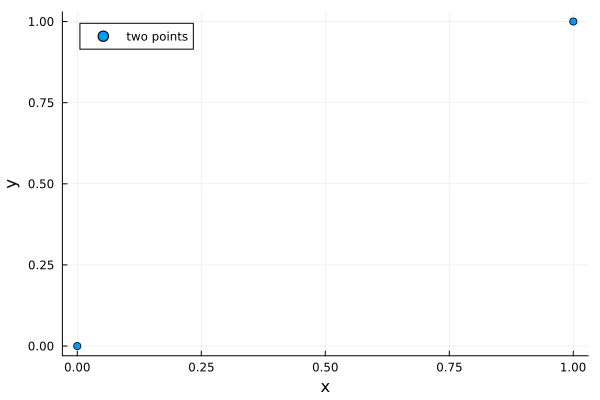

In [17]:
scatter([0, 1], [0, 1]; xlabel="x", ylabel="y", label="two points")

<div dir="rtl" style="text-align:right">
<p dir="rtl" style="text-align:right">فحص الخط الدقيق من صندوق الرياضيات: ميل 2، وتقاطع 1، وبواقٍ صفرية. ينبغي أن تستعيدها وصفة المجموع الممركز المرفقة نفسها.</p>
</div>

In [18]:
check_x = [0.0, 1.0, 2.0]
check_y = [1.0, 3.0, 5.0]
check_xbar = sum(check_x) / 3
check_ybar = sum(check_y) / 3
check_slope = sum((check_x .- check_xbar) .* (check_y .- check_ybar)) / sum((check_x .- check_xbar).^2)
check_intercept = check_ybar - check_slope * check_xbar
check_residuals = check_y .- (check_slope .* check_x .+ check_intercept)
(check_slope, check_intercept, check_residuals)

(2.0, 1.0, [0.0, 0.0, 0.0])

<div dir="rtl" style="text-align:right">
<h2 id="الختام-والتأمل">الختام والتأمل</h2>
<p dir="rtl" style="text-align:right">نشرح نتيجة واحدة بالكلمات، ونذكر وحداتها أو افتراضاتها حين يلزم، ونحدّد فحصًا قد يكشف خطأ. تصف فقرات التمرين والواجب والمكافأة الاختيارية والاستزادة أعلاه الخطوات التالية. لا تصبح الخلفية الاختيارية شرطًا للامتحان.</p>
</div>